In [1]:
import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import matplotlib.pyplot as plt

import plotly.graph_objects as go
import networkx as nx

import os

from scipy.spatial.distance import cdist

import time

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Firedrake environment

In [2]:
# Load everything
all_geodesic_distances = np.load('teddy_exact_geodesic_distances_graph.npy') # ('teddy_geodesic_distances.npy')
vertices = np.load('teddy_vertices.npy')
faces = np.load('teddy_faces.npy')
y_values = np.load('teddy_y_values.npy')

print("Done")

Done


In [ ]:

# Create mesh plot with y-values as colors
fig = go.Figure(data=[
    go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=y_values,  # Color by y-values
        colorscale='plasma',  # Or 'RdBu', 'Plasma', etc.
        colorbar=dict(title="Y value"),
        showscale=True
    )
])

# Clean up the figure (using your update_figure function)
fig.update_layout(scene_aspectmode="auto")
fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.update_layout(
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=0, y=0.9, z=1.8)   # zoom out: increase from 0.7/1.25
    )
)

fig.show()
fig.write_image("/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Teddy Bear Results/Ground Truth.pdf", width=1200, height=800)

In [14]:
def plot_geodesic(source, target, vertices, faces, y_values, mesh_graph, opacity=0.85):
    """
    Plot the geodesic path between two vertices on the teddy mesh.

    Parameters
    ----------
    source     : int   — start vertex index
    target     : int   — end vertex index
    vertices   : np.ndarray (n, 3)
    faces      : np.ndarray (f, 3)
    y_values   : np.ndarray (n,)
    mesh_graph : nx.Graph  — prebuilt weighted mesh graph
    opacity    : float     — mesh transparency (default 0.85)

    Returns
    -------
    fig : plotly Figure
    """
    # Validate indices
    n = len(vertices)
    assert 0 <= source < n, f"source {source} out of range [0, {n-1}]"
    assert 0 <= target < n, f"target {target} out of range [0, {n-1}]"

    # Geodesic path
    path_vertices = nx.shortest_path(mesh_graph, source=source, target=target, weight='weight')
    path_coords   = vertices[path_vertices]
    path_length   = sum(
        np.linalg.norm(vertices[path_vertices[i+1]] - vertices[path_vertices[i]])
        for i in range(len(path_vertices) - 1)
    )

    print(f"Geodesic: vertex {source} → vertex {target}")
    print(f"  Hops:   {len(path_vertices) - 1}")
    print(f"  Length: {path_length:.4f}")

    # Build figure
    fig = go.Figure()

    # Mesh
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=y_values,
        colorscale='Viridis',
        colorbar=dict(title="Y value"),
        showscale=True,
        opacity=opacity,
    ))

    # Geodesic line
    fig.add_trace(go.Scatter3d(
        x=path_coords[:, 0],
        y=path_coords[:, 1],
        z=path_coords[:, 2],
        mode='lines',
        line=dict(color='red', width=6),
        name=f'Geodesic (len={path_length:.2f})',
    ))

    # Start point
    fig.add_trace(go.Scatter3d(
        x=[vertices[source, 0]],
        y=[vertices[source, 1]],
        z=[vertices[source, 2]],
        mode='markers+text',
        marker=dict(color='lime', size=8),
        text=[f'Start ({source})'],
        textposition='top center',
        name='Start',
    ))

    # End point
    fig.add_trace(go.Scatter3d(
        x=[vertices[target, 0]],
        y=[vertices[target, 1]],
        z=[vertices[target, 2]],
        mode='markers+text',
        marker=dict(color='yellow', size=8),
        text=[f'End ({target})'],
        textposition='top center',
        name='End',
    ))

    fig.update_layout(scene_aspectmode="auto")
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    fig.update_layout(
        margin=dict(l=0, r=0, t=40, b=0),
        title=f"Geodesic: vertex {source} → {target}  |  length={path_length:.3f}  |  hops={len(path_vertices)-1}",
        scene_camera=dict(
            up=dict(x=0, y=1, z=0),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=0, y=0.7, z=1.25)
        )
    )

    return fig

# ============================================================================
# 2. BUILD MESH GRAPH
# ============================================================================
def build_mesh_graph(vertices, faces):
    G = nx.Graph()
    G.add_nodes_from(range(len(vertices)))
    for face in faces:
        face = list(face)
        n = len(face)
        for k in range(n):
            u = face[k]
            v = face[(k + 1) % n]
            if u != v and not G.has_edge(u, v):
                weight = float(np.linalg.norm(vertices[u] - vertices[v]))
                G.add_edge(u, v, weight=weight)
    return G

print("🔧 Constructing mesh graph...")
mesh_graph = build_mesh_graph(vertices, faces)
print("Mesh graph built")

🔧 Constructing mesh graph...
Mesh graph built


In [15]:
fig = plot_geodesic(1000, 1400, vertices, faces, y_values, mesh_graph)
fig.show()

Geodesic: vertex 1000 → vertex 1400
  Hops:   16
  Length: 32.7202


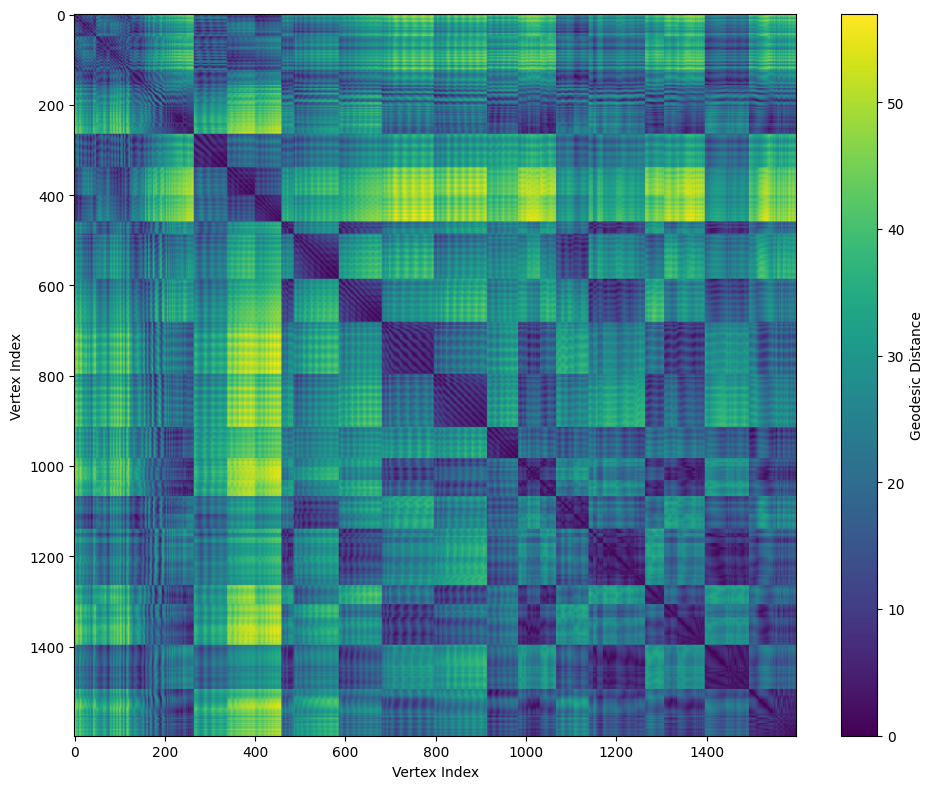

In [16]:
plt.figure(figsize=(10, 8))
im = plt.imshow(all_geodesic_distances, cmap='viridis') # [:20,:20]
plt.colorbar(im, label='Geodesic Distance')
plt.xlabel('Vertex Index')
plt.ylabel('Vertex Index')
plt.tight_layout()
plt.show()

In [7]:
# # ============================================================================
# # DIAGNOSE Geodesic Distance Matrix: vertices 1000 and 1400
# # ============================================================================
# source, target = 1000, 1400

# geo_d    = all_geodesic_distances[source, target]
# eucl_d   = np.linalg.norm(vertices[source] - vertices[target])
# path     = nx.shortest_path(mesh_graph, source=source, target=target, weight='weight')
# path_len = sum(np.linalg.norm(vertices[path[i+1]] - vertices[path[i]])
#                for i in range(len(path) - 1))

# print(f"Vertex {source} position: {vertices[source]}")
# print(f"Vertex {target} position: {vertices[target]}")
# print(f"")
# print(f"Euclidean distance:        {eucl_d:.4f}")
# print(f"Geodesic (matrix):         {geo_d:.4f}")
# print(f"Geodesic (path sum):       {path_len:.4f}")
# print(f"Ratio geo/eucl:            {geo_d/eucl_d:.4f}")
# print(f"Path hops:                 {len(path) - 1}")
# print(f"")

# # Where do these sit in the overall distribution?
# off_diag = all_geodesic_distances[~np.eye(len(all_geodesic_distances), dtype=bool)]
# pct = np.mean(off_diag < geo_d) * 100
# print(f"geo[{source},{target}] = {geo_d:.4f} is in the {pct:.1f}th percentile")
# print(f"  (i.e. {pct:.1f}% of all vertex pairs are CLOSER than this)")
# print(f"")
# print(f"Overall distance range: [{off_diag.min():.4f}, {off_diag.max():.4f}]")
# print(f"Overall mean:            {off_diag.mean():.4f}")

In [17]:
# Mask diagonal then find max
n = all_geodesic_distances.shape[0]
geo_masked = all_geodesic_distances.copy()
np.fill_diagonal(geo_masked, 0)

max_idx = np.unravel_index(np.argmax(geo_masked), geo_masked.shape)
source, target = max_idx

print(f"Maximum geodesic distance: {all_geodesic_distances[source, target]:.4f}")
print(f"Vertex indices: {source} → {target}")
print(f"Vertex {source} position: {vertices[source]}")
print(f"Vertex {target} position: {vertices[target]}")
print(f"Euclidean distance: {np.linalg.norm(vertices[source] - vertices[target]):.4f}")

# Also show top 5 pairs (upper triangle only to avoid duplicates)
print("\n--- Top 5 Most Distant Pairs ---")
upper = np.triu(geo_masked, k=1)
flat  = upper.flatten()
top5  = np.argsort(flat)[-5:][::-1]
for idx in top5:
    i, j = np.unravel_index(idx, geo_masked.shape)
    print(f"  [{i:4d}, {j:4d}]  geodesic={all_geodesic_distances[i,j]:.4f}  euclidean={np.linalg.norm(vertices[i]-vertices[j]):.4f}")

Maximum geodesic distance: 56.9255
Vertex indices: 443 → 791
Vertex 443 position: [-5.24744  20.6272    0.424129]
Vertex 791 position: [  5.25209 -19.6122    9.17352]
Euclidean distance: 42.4971

--- Top 5 Most Distant Pairs ---
  [ 443,  791]  geodesic=56.9255  euclidean=42.4971
  [ 444,  791]  geodesic=56.7971  euclidean=42.5337
  [ 444,  772]  geodesic=56.7266  euclidean=43.2366
  [ 443,  772]  geodesic=56.7204  euclidean=43.2125
  [ 451,  792]  geodesic=56.6506  euclidean=42.9132


In [18]:
fig = plot_geodesic(source, target, vertices, faces, y_values, mesh_graph)
fig.show()

Geodesic: vertex 443 → vertex 791
  Hops:   33
  Length: 56.9255


# Running One GP model training

In [19]:
vertices

array([[ -4.75738,   8.49991,   8.28592],
       [ -4.55816,  11.4788 ,   7.74909],
       [ -4.37277,  13.9925 ,   6.2828 ],
       ...,
       [  6.44628, -14.1865 ,  -6.82055],
       [  5.00347, -16.345  ,  -5.4749 ],
       [  6.98854, -16.9314 ,  -3.18964]], shape=(1598, 3))

In [20]:
# Step 1: First sample the subset of points
np.random.seed(3256)

# Step 3: Now split the subset into train and test
n_train = 1500 # 50
n_test = 50

# Sample ALL indices at once, then split
indices_all = np.random.choice(len(vertices), size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
#x_train = vertices[indices_train,:]
x_train = indices_train.reshape(-1,1)
y_train = y_values[indices_train]

# x_test = vertices[indices_test,:]
x_test = indices_test.reshape(-1,1)
y_test = y_values[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

indices_train_sort = np.sort(indices_train)


Training points: 1500
Test points: 50


In [21]:
# Step 2 (Fixed): Define the basic GP components
def matern_kernel_diff2(distance, length):
    """
    Function for the Matern kernel, order of differentiability = 2.
    kernel = (
        1.0
        + ((np.sqrt(5.0) * distance) / (length))
        + ((5.0 * distance ** 2) / (3.0 * length ** 2))
    ) * np.exp(-(np.sqrt(5.0) * distance) / length)

    Parameters
    ----------
    distance : scalar or np.ndarray
        Distance between a set of points.
    length : scalar
        The length scale hyperparameters.

    Return
    ------
    Kernel output : same as distance parameter.
    """

    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel



def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

def bump_k(x1, x2, hps):

    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    # We want shape: (len(x1), n_train) - each row is one x1 point's distances to all training points
    d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
    
    # Matern on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))

    #return hps[0] * np.exp(-D_mat**2 / hps[3]) #, D_mat
    
    return hps[0] * matern_kernel_diff2(D_mat, hps[3])
    

def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [22]:
# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_train)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = all_geodesic_distances[np.ix_(x_train.flatten(), x_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((5, 2))
bounds[0] = np.array([1e2, 1e6])   # 1e6                                     # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # bump radius
bounds[2] = np.array([1e-1,50])                                              # bump amplitude
bounds[3] = np.array([1e-3, 50])                                             # Exponential lengthscale
#bounds[4] = np.array([1e-5, 1])                                             # bump beta
bounds[4] = np.array([1e-6, 10])                                             # Noise variance

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  Bump Amplitude:  [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  RBF length:      [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")
#print(f"  Bump Beta:       [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")
print(f"  Noise Variance:  [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [100.000000, 1000000.000000]
  Bump radius:     [0.003835, 56.726562]
  Bump Amplitude:  [0.100000, 50.000000]
  RBF length:      [0.001000, 50.000000]
  Noise Variance:  [0.000001, 10.000000]


In [ ]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)

trained_hps = np.array([1.47842468e+04, 1.87316382e+01, 8.68944986e+00, 4.81137217e+01, 2.75896743e-05])

print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=trained_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# # Step 5: Train the GP model
#  my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global')#, max_iter=15000)

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")

# Final hyperparameters:   [8.27802483e+01 7.58312895e-01 4.99824805e+02 1.81358351e-02 1.07441620e-01]  # Test RMSE: 0.42


Initial hyperparameters: [5.0005000e+05 2.8365199e+01 2.5050000e+01 2.5000500e+01 5.0000005e+00]
Initial log likelihood: -10561.435252
Final hyperparameters:   [1.47842468e+04 1.87316382e+01 8.68944986e+00 4.81137217e+01
 2.75896743e-05]
Final log likelihood:    -5713.51


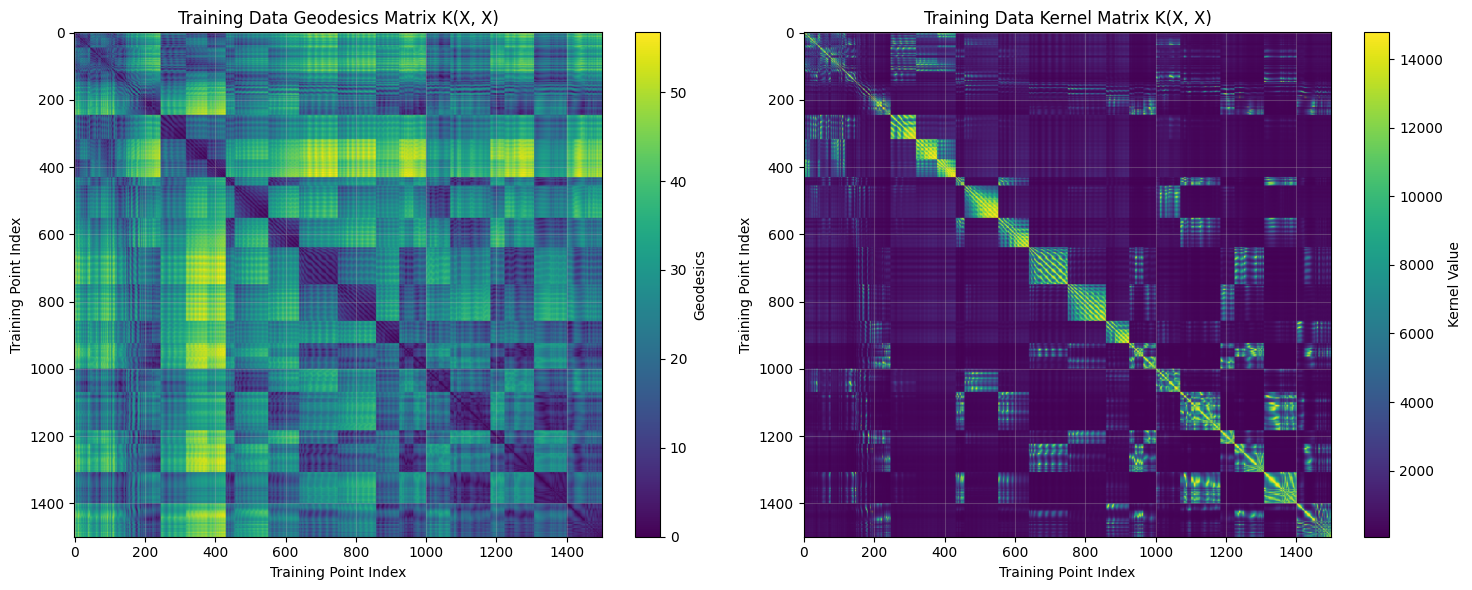

In [24]:
# final_hps = np.array([3.96507623e+03, 2.28840840e+00, 4.97484097e-01])

hps_to_be_used = np.array([3.96507623e+03, 50, 100]) # 4.97484097e-01

indices_train_sort = np.sort(indices_train)
my_kernel = bump_k(indices_train_sort,indices_train_sort, final_hps)

# Create the visualization with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Geodesic distances
im1 = axes[0].imshow(all_geodesic_distances[np.ix_(indices_train_sort, indices_train_sort)], 
                      cmap='viridis', aspect='auto')
plt.colorbar(im1, ax=axes[0], label='Geodesics')
axes[0].set_title('Training Data Geodesics Matrix K(X, X)')
axes[0].set_xlabel('Training Point Index')
axes[0].set_ylabel('Training Point Index')
axes[0].grid(True, alpha=0.3)

# Right plot: Kernel matrix
im2 = axes[1].imshow(my_kernel, cmap='viridis', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Kernel Value')
axes[1].set_title('Training Data Kernel Matrix K(X, X)')
axes[1].set_xlabel('Training Point Index')
axes[1].set_ylabel('Training Point Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(1500, 1500)


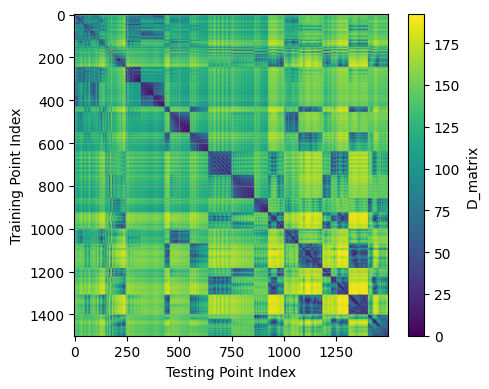

In [25]:
def bump_k_withDmat(x1, x2, hps):

    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train)]  # Shape: (len(x2), n_train)
    
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)

    print(phi_x1.shape)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    return hps[0] * np.exp(-D_mat**2 / hps[3]) , D_mat, phi_x1, phi_x2
    

x_train_sorted = indices_train_sort

indices_test_sort = np.sort(indices_test)

my_kernel, D_mat,phi_x1, phi_x2 = bump_k_withDmat(indices_train_sort,indices_train_sort, final_hps)


# Create the visualization
plt.figure(figsize=(5, 4))
im = plt.imshow(D_mat, cmap='viridis', aspect='auto')
plt.colorbar(im, label='D_matrix')
#plt.title('Training Data Kernel Matrix K(X, X)')
plt.xlabel('Testing Point Index')
plt.ylabel('Training Point Index')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

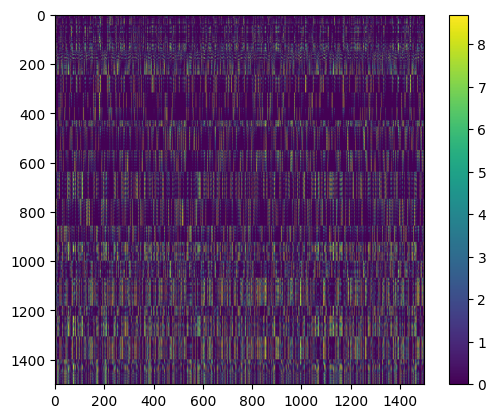

In [26]:
plt.imshow(phi_x1)
plt.colorbar()

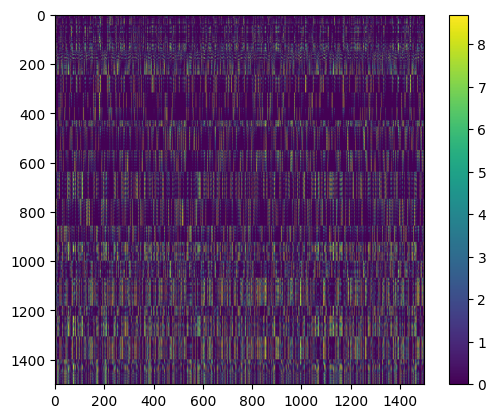

In [27]:
plt.imshow(phi_x2)
plt.colorbar()

In [30]:
vertices

array([[ -4.75738,   8.49991,   8.28592],
       [ -4.55816,  11.4788 ,   7.74909],
       [ -4.37277,  13.9925 ,   6.2828 ],
       ...,
       [  6.44628, -14.1865 ,  -6.82055],
       [  5.00347, -16.345  ,  -5.4749 ],
       [  6.98854, -16.9314 ,  -3.18964]], shape=(1598, 3))

In [34]:
x_test = np.arange(0,len(vertices),1).reshape(-1,1)
x_test

array([[   0],
       [   1],
       [   2],
       ...,
       [1595],
       [1596],
       [1597]], shape=(1598, 1))

In [33]:
x_train

array([[ 926],
       [  81],
       [ 580],
       ...,
       [ 880],
       [ 730],
       [1226]], shape=(1500, 1))

In [36]:
x_test = np.arange(0,len(vertices),1).reshape(-1,1)

f_pred = my_gpo.posterior_mean(x_test)["m(x)"]

# Create mesh plot with y-values as colors
fig = go.Figure(data=[
    go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=f_pred,  # Color by y-values
        colorscale='plasma',  # Or 'RdBu', 'Plasma', etc.
        colorbar=dict(title="Y value"),
        showscale=True
    )
])

# Clean up the figure (using your update_figure function)
fig.update_layout(scene_aspectmode="auto")
fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.update_layout(
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=0, y=0.9, z=1.8)   # zoom out: increase from 0.7/1.25
    )
)

fig.show()
fig.write_image("/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Teddy Bear Results/Predictions.pdf", width=1200, height=800)

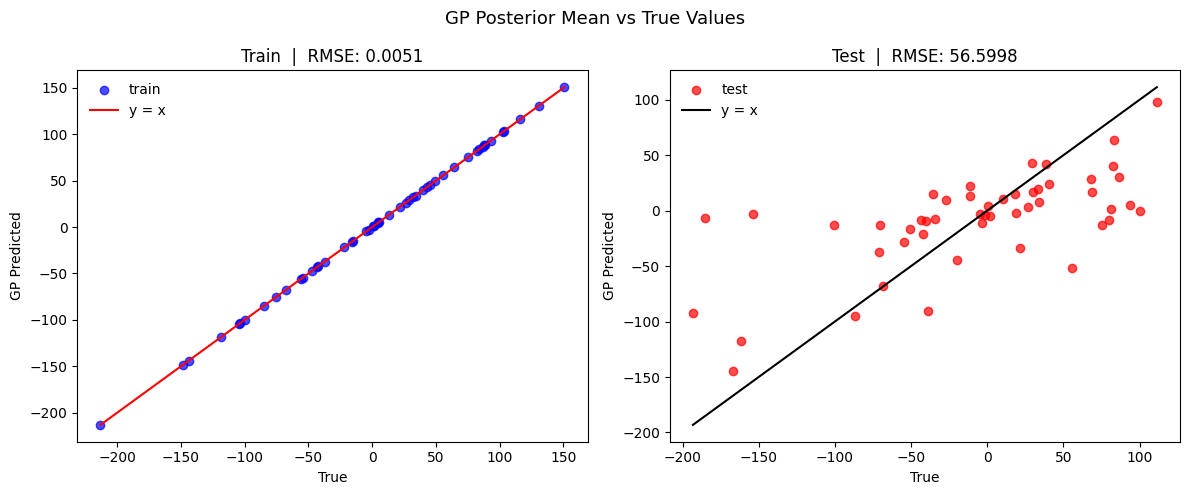

Train RMSE: 0.0051
Test  RMSE: 56.5998


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Train ──────────────────────────────────────────────────────────────
f_train = my_gpo.posterior_mean(x_train)["m(x)"]
rmse_train = my_gpo.rmse(x_train, y_train)

my_line_train = np.linspace(np.min(y_train), np.max(y_train), 10)

axes[0].scatter(y_train, f_train, color="blue", label="train", alpha=0.7)
axes[0].plot(my_line_train, my_line_train, c="red", label="y = x")
axes[0].set_xlabel("True")
axes[0].set_ylabel("GP Predicted")
axes[0].set_title(f"Train  |  RMSE: {rmse_train:.4f}")
axes[0].legend(frameon=False)

# ── Right: Test ───────────────────────────────────────────────────────────────
f_test = my_gpo.posterior_mean(x_test)["m(x)"]
rmse_test = my_gpo.rmse(x_test, y_test)

my_line_test = np.linspace(np.min(y_test), np.max(y_test), 10)

axes[1].scatter(y_test, f_test, color="red", label="test", alpha=0.7)
axes[1].plot(my_line_test, my_line_test, c="black", label="y = x")
axes[1].set_xlabel("True")
axes[1].set_ylabel("GP Predicted")
axes[1].set_title(f"Test  |  RMSE: {rmse_test:.4f}")
axes[1].legend(frameon=False)

plt.suptitle("GP Posterior Mean vs True Values", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")

In [18]:
crps_test = my_gpo.crps(x_test, y_test)
print(crps_test)

from scipy.stats import norm

def picp(my_gpo, x_test, y_true, interval=0.95):
        mu = my_gpo.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(my_gpo.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
    
picp_test = picp(my_gpo, x_test, y_test)
print(picp_test)


(np.float64(30.204451548650106), np.float64(25.205901581829597))
0.92


# Making several trials with different training size

In [2]:
import json
from tqdm import tqdm

import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

from scipy.spatial.distance import cdist
from scipy.stats import norm

import time

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

In [3]:
# Load everything
all_geodesic_distances = np.load('teddy_exact_geodesic_distances_graph.npy')
vertices = np.load('teddy_vertices.npy')
faces = np.load('teddy_faces.npy')
y_values = np.load('teddy_y_values.npy')

print("Done")

Done


In [4]:
# def generate_training_configurations():
#     # Configuration
#     training_sizes = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800]
#     n_trials = 100
#     total_data_points = 1598 #len(vertices)
    
#     # Generate 100 random seeds
#     np.random.seed(42)
#     random_seeds = np.random.randint(1, 100000, size=n_trials)
    
#     # Generate single test set FIRST
#     np.random.seed(9999)
#     test_indices = np.random.choice(total_data_points, size=500, replace=False).tolist()
#     test_indices_set = set(test_indices)  # For fast lookup
    
#     # Create pool of available training indices (exclude test set)
#     available_train_indices = [i for i in range(total_data_points) if i not in test_indices_set]
    
#     # Structure to store all configurations
#     training_configs = {
#         "test_indices": test_indices,
#         "training_configurations": {}
#     }
    
#     print(f"Generating configurations for {len(training_sizes)} training sizes...")
#     print(f"Each size will have {n_trials} trials")
#     print(f"Available training pool: {len(available_train_indices)} (after excluding {len(test_indices)} test samples)")
    
#     for train_size in tqdm(training_sizes, desc="Training sizes"):
#         train_size_configs = []
        
#         for trial_idx in tqdm(range(n_trials), desc=f"Size {train_size}", leave=False):
#             seed = int(random_seeds[trial_idx])
            
#             # Set seed and generate indices
#             np.random.seed(seed)
#             random.seed(seed)
            
#             # Sample from AVAILABLE indices only (excluding test set)
#             indices_train = random.sample(available_train_indices, train_size)
            
#             # Store configuration for this trial
#             trial_config = {
#                 "seed": seed,
#                 "indices_train": indices_train
#             }
            
#             train_size_configs.append(trial_config)
        
#         # Store all trials for this training size
#         training_configs["training_configurations"][str(train_size)] = train_size_configs
    
#     return training_configs

# # Generate the configurations
# print("Generating training configurations...")
# training_configs = generate_training_configurations()

# # Save to JSON file
# with open('teddy_example_training_configurations.json', 'w') as f:
#     json.dump(training_configs, f, indent=2)

# print(f"✅ Saved training configurations to 'training_configurations.json'")
# print(f"📊 Test indices: {len(training_configs['test_indices'])}")
# print(f"📊 Training sizes: {len(training_configs['training_configurations'])}")
# print(f"🎯 Total trials: {sum(len(trials) for trials in training_configs['training_configurations'].values())}")

In [5]:
def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]  # hps[3]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [6]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    #x_test = vertices[test_indices]
    x_test = np.array(test_indices).reshape(-1,1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    #x_train = vertices[indices_train]
    x_train = np.array(indices_train).reshape(-1,1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(y_train,indices_train):

    # 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
    y_var = np.var(y_train)
    
    # 2. Bump radius (hps[1]): [min distance, maximum distance]
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    # Define hyperparameter bounds
    bounds = np.empty((5, 2))
    bounds[0] = np.array([1e2, 1e6])   # 1e6                                     # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # bump radius
    bounds[2] = np.array([1e-1,10])                                              # bump amplitude
    bounds[3] = np.array([1e-3, 40])                                             # Exponential lengthscale
    bounds[4] = np.array([1e-6,10])                                              # Noise variance
    return bounds


def matern_kernel_diff2(distance, length):
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel
    
def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)


    def bump(d, r, beta, ampl):
        """
        Bump function for the kernel
        d: distances (can be any shape)
        r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
        beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
        ampl: amplitude
        """
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        # Only compute where a > 0
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k_multiple_trials(x1, x2, hps):
    
        # x1 and x2 ARE the indices - just extract them
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        # Extract geodesic distances
        # d1: distances from x1 points to training points
        # We want shape: (len(x1), n_train) - each row is one x1 point's distances to all training points
        d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train_trials)]  # Shape: (len(x1), n_train)
        d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train_trials)]  # Shape: (len(x2), n_train)
        
        # Apply bump to create embedding
        # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
        phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
        phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
        
        # Matern on embeddings
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
        
        #return hps[0] * np.exp(-D_mat**2 / hps[3]) #, D_mat
        return hps[0] * matern_kernel_diff2(D_mat, hps[3])
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k_multiple_trials,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=4000)
    
    return my_gpo



def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'teddy_example_gp_experiment_results_Matern_chgAmpl.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, vertices, y_values)
    print(f"Test data shape: x: {x_test.shape}, y: {y_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train_trials = get_training_data(configs, train_size, trial_idx, vertices, y_values)

                ##################
                # Make x_train global so kernel functions can access it
                globals()['x_train'] = x_train  # ← Add this line
                globals()['y_train'] = y_train
                globals()['indices_train_trials'] = indices_train_trials  # if bump_k needs this too
                ##################
                

                # Identify the hps bounds
                bounds_trials = get_hps_bounds(y_train,indices_train_trials)

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds_trials)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)

                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial ✅
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} ✅ Saved")
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

🚀 Starting GP experiments...
Loading configurations...
📂 Loaded 369 existing results
Test data shape: x: (500, 1), y: (500,)

=== Training Size: 50 ===


Size 50: 100%|██████████| 30/30 [00:00<00:00, 93206.76it/s]


  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

Size 100: 100%|██████████| 30/30 [00:00<00:00, 75846.37it/s]


  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

...

  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

Size 800:   0%|          | 0/30 [00:00<?, ?it/s]

  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)


Size 800: 100%|██████████| 30/30 [9:01:31<00:00, 1083.04s/it]  

🎉 Completed! Total experiments: 390


In [ ]:
# # delete the cases with errors:

# import json

# # Load the JSON file
# with open('dragon_example_gp_experiment_results.json', 'r') as f:
#     data = json.load(f)

# # Keep only entries 0-379 (delete 380 onwards)
# data_trimmed = data[:380]

# # Save back to the same file
# with open('dragon_example_gp_experiment_results.json', 'w') as f:
#     json.dump(data_trimmed, f, indent=2)

# print(f"Original entries: {len(data)}")
# print(f"Trimmed entries: {len(data_trimmed)}")
# print(f"Deleted: {len(data) - len(data_trimmed)} entries")


# One Model at a time

In [ ]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = vertices[test_indices]
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = vertices[indices_train]
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(y_train,indices_train):

    # 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
    y_var = np.var(y_train)
    
    # 2. Bump radius (hps[1]): [min distance, maximum distance]
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    # Define hyperparameter bounds
    bounds = np.empty((3, 2))
    bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
    bounds[2] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings
    
    return bounds

def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='mcmc', 
                 max_iter=4000)
    
    return my_gpo



"""Run all GP experiments and save results incrementally"""

# Load configurations
print("Loading configurations...")
json_file_name = 'teddy_example_training_configurations.json'
configs = load_configurations(json_file_name)


# Get fixed test data
#print("Loading test data...")
x_test, y_test = get_test_data(configs, vertices, y_values)
#print(f"Test data shape: {x_test.shape}")

# Get all training sizes
training_sizes = list(configs['training_configurations'].keys())
training_sizes = [int(size) for size in training_sizes]
training_sizes.sort()

#print(f"Training sizes: {training_sizes}")
#print(f"Starting experiments...")

# Main experiment loop
for train_size in training_sizes:
    print(f"\n=== Training Size: {train_size} ===")
    
    trials = configs['training_configurations'][str(train_size)]
    
    #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
    for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):

    
    
        # Get training data for this trial
        x_train, y_train, seed, indices_train = get_training_data(configs, train_size, trial_idx, vertices, y_values)


        ##################
        # Make x_train global so kernel functions can access it
        globals()['x_train'] = x_train  # ← Add this line
        globals()['y_train'] = y_train
        globals()['indices_train'] = indices_train  # if bump_k needs this too
        ##################
        
        # Identify the hps bounds
        bounds = get_hps_bounds(y_train,indices_train)

        # Train GP model
        my_gpo = train_gp_model(x_train, y_train, bounds)
        
        # Calculate training RMSE
        train_rmse = my_gpo.rmse(x_train, y_train)
        
        # Calculate testing RMSE
        test_rmse = my_gpo.rmse(x_test, y_test)
        
        # Get final hyperparameters and log likelihood
        final_hps = my_gpo.get_hyperparameters()
        final_ll = my_gpo.log_likelihood(final_hps)
        
        # Store results
        result = {
            'training_size': train_size,
            'trial': trial_idx,
            'seed': seed,
            'train_rmse': float(train_rmse),
            'test_rmse': float(test_rmse),
            'final_log_likelihood': float(final_ll),
            'final_hyperparameters': final_hps.tolist(),
            'n_training_points': len(x_train),
        }
        
        